# 03 — Feature Selection & Model Training

**Purpose:** Load the clean, encoded splits produced by Notebook 02, run four
statistical tests to identify the 10 best predictors of `SalePrice`, validate
the selection, train and compare four candidate models, then serialize the winner.

**Inputs** : `data/processed/` — six CSV splits + `feature_metadata.json`
**Outputs** : `models/best_model_v1.joblib`, `models/training_stats.json`
**Prerequisite** : Notebook 02 must have been executed first.

> **Why load from `data/processed/`?**
> Notebook 02 already handles the 60/20/20 split, domain-driven imputation,
> feature engineering (`TotalSF`, `TotalBath`, `HouseAge`, `HasRemodel`),
> ordinal encoding, one-hot encoding, and StandardScaling. Repeating those
> steps here would reintroduce the risk of data leakage and create two
> inconsistent preprocessing paths.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway, pearsonr, spearmanr
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

ROOT         = Path("..") if Path("../data").exists() else Path(".")
PROCESSED    = ROOT / "data" / "processed"
MODEL_DIR    = ROOT / "models"
MODEL_PATH   = MODEL_DIR / "best_model_v1.joblib"
STATS_PATH   = MODEL_DIR / "training_stats.json"
MODEL_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
print("Libraries loaded.")

Libraries loaded.


📝 **What's happening here**

One import cell, no preprocessing libraries — because all encoding and scaling
is already done. Key packages:

| Library | Role |
|---------|------|
| `scipy.stats` | Pearson r, Spearman ρ, one-way ANOVA |
| `sklearn.feature_selection` | Mutual Information regression |
| `statsmodels` | VIF for multicollinearity check |
| `sklearn.pipeline.Pipeline` | Wraps the model (no `ColumnTransformer` needed — data is already clean) |

## 1) Load Processed Data

In [2]:
# ── Load the six split CSVs produced by Notebook 02 ─────────────────────────
X_train = pd.read_csv(PROCESSED / "X_train.csv", index_col=0)
X_val   = pd.read_csv(PROCESSED / "X_val.csv",   index_col=0)
X_test  = pd.read_csv(PROCESSED / "X_test.csv",  index_col=0)

y_train = pd.read_csv(PROCESSED / "y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(PROCESSED / "y_val.csv",   index_col=0).squeeze()
y_test  = pd.read_csv(PROCESSED / "y_test.csv",  index_col=0).squeeze()

print(f"X_train : {X_train.shape}   y_train : {len(y_train):,}")
print(f"X_val   : {X_val.shape}     y_val   : {len(y_val):,}")
print(f"X_test  : {X_test.shape}    y_test  : {len(y_test):,}")

# Quick sanity checks
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    nulls = X.isnull().sum().sum()
    assert nulls == 0, f"Nulls found in X_{name}!"
print("\n✓ Zero nulls across all splits — Notebook 02 contract holds.")

X_train : (1757, 268)   y_train : 1,757
X_val   : (586, 268)     y_val   : 586
X_test  : (586, 268)    y_test  : 586

✓ Zero nulls across all splits — Notebook 02 contract holds.


📝 **What's happening here**

We load the six files produced by Notebook 02. The `index_col=0` argument
preserves the original row indices from the split — without it, pandas adds
a new 0-based index that misaligns `X` and `y` when we join them for analysis.

`y_*.csv` files each contain a single column; `.squeeze()` converts the
one-column DataFrame to a named Series so downstream pandas operations
(`.groupby()`, arithmetic) work cleanly.

The zero-null assertion is a **contract check** — it fails fast if Notebook 02
was not executed, or if its output files were corrupted or accidentally deleted.

In [3]:
# ── Load feature metadata written by Notebook 02 ────────────────────────────
with open(PROCESSED / "feature_metadata.json") as f:
    meta = json.load(f)

NUMERIC_FEATURES  = meta["numeric_features"]
ORDINAL_FEATURES  = meta["ordinal_features"]
NOMINAL_FEATURES  = meta["nominal_features"]

# OHE columns for each nominal feature (e.g. "Neighborhood_NridgHt")
OHE_COLS = {
    nom: [c for c in X_train.columns if c.startswith(nom + "_")]
    for nom in NOMINAL_FEATURES
}

print("Feature groups from Notebook 02:")
print(f"  Numeric  ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES[:6]} ...")
print(f"  Ordinal  ({len(ORDINAL_FEATURES)}): {ORDINAL_FEATURES}")
print(f"  Nominal  ({len(NOMINAL_FEATURES)}): {NOMINAL_FEATURES}")
for nom, cols in OHE_COLS.items():
    print(f"    {nom} → {len(cols)} OHE columns")
print(f"\nTotal columns in processed data: {X_train.shape[1]}")

Feature groups from Notebook 02:
  Numeric  (41): ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt'] ...
  Ordinal  (10): ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
  Nominal  (33): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
    MSZoning → 6 OHE columns
    Street → 2 OHE columns
    Alley → 3 OHE columns
    LotShape → 4 OHE columns
    LandContour → 4 OHE columns
    Utilities → 3 OHE columns
    LotConfig → 5 OHE columns
    LandSlope → 3 OHE columns
    Neighborho

📝 **What's happening here**

`feature_metadata.json` is the handoff contract from Notebook 02. It records:

- **`numeric_features`** — original numeric columns (now StandardScaled)
- **`ordinal_features`** — quality columns (now 0–5 integers via OrdinalEncoder)
- **`nominal_features`** — categorical columns that were one-hot encoded

The total column count (~268) is much larger than the number of *original*
features because each nominal category became its own binary column. For example,
`Neighborhood` (25 unique values) became 25 columns like `Neighborhood_NridgHt`.

The feature selection in §2 will work on *original* feature names, aggregating
scores from the OHE columns back to their source feature.

## 2) Statistical Feature Selection

### 2a) Define Candidate Pool

In [4]:
# We test a curated subset of ~20 original features — a mix of numeric,
# ordinal, and nominal — to demonstrate the selection process.
# All of these columns exist in the processed data (already encoded/scaled).

NUMERIC_CANDIDATES = [
    # Engineered (NB02 §8)
    "TotalSF", "TotalBath", "HouseAge", "HasRemodel",
    # Key raw numerics
    "OverallQual", "OverallCond", "GarageCars", "GarageArea",
    "TotalBsmtSF", "GrLivArea", "LotArea",
    "BedroomAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "YearBuilt", "YearRemodAdd",
]
ORDINAL_CANDIDATES = [c for c in ORDINAL_FEATURES
                      if c in ["KitchenQual", "ExterQual", "BsmtQual", "HeatingQC",
                               "FireplaceQu", "GarageQual"]]
NOMINAL_CANDIDATES = NOMINAL_FEATURES   # all nominals from NB02

# Keep only candidates that actually exist in the processed data
NUMERIC_CANDIDATES = [c for c in NUMERIC_CANDIDATES if c in X_train.columns]
ORDINAL_CANDIDATES = [c for c in ORDINAL_CANDIDATES if c in X_train.columns]

print(f"Candidate pool:")
print(f"  Numeric  ({len(NUMERIC_CANDIDATES)}): {NUMERIC_CANDIDATES}")
print(f"  Ordinal  ({len(ORDINAL_CANDIDATES)}): {ORDINAL_CANDIDATES}")
print(f"  Nominal  ({len(NOMINAL_CANDIDATES)}): {NOMINAL_CANDIDATES}")
print(f"  Total    : {len(NUMERIC_CANDIDATES)+len(ORDINAL_CANDIDATES)+len(NOMINAL_CANDIDATES)} original features")

Candidate pool:
  Numeric  (16): ['TotalSF', 'TotalBath', 'HouseAge', 'HasRemodel', 'OverallQual', 'OverallCond', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'GrLivArea', 'LotArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'YearBuilt', 'YearRemodAdd']
  Ordinal  (6): ['ExterQual', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual']
  Nominal  (33): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
  Total    : 55 original features


📝 **What's happening here**

We define a **candidate pool** of roughly 20 original features drawn from three
types. Since Notebook 02 already encoded everything, the numeric and ordinal
candidates are direct scalar columns in `X_train`. Nominal candidates are
represented by their OHE column groups — we will aggregate their scores in
each test.

The goal of this section is to rank all candidates statistically and pick the
10 features that carry the most predictive signal for `SalePrice` with the
least redundancy.

### 2b) Pearson Correlation (numeric + ordinal)

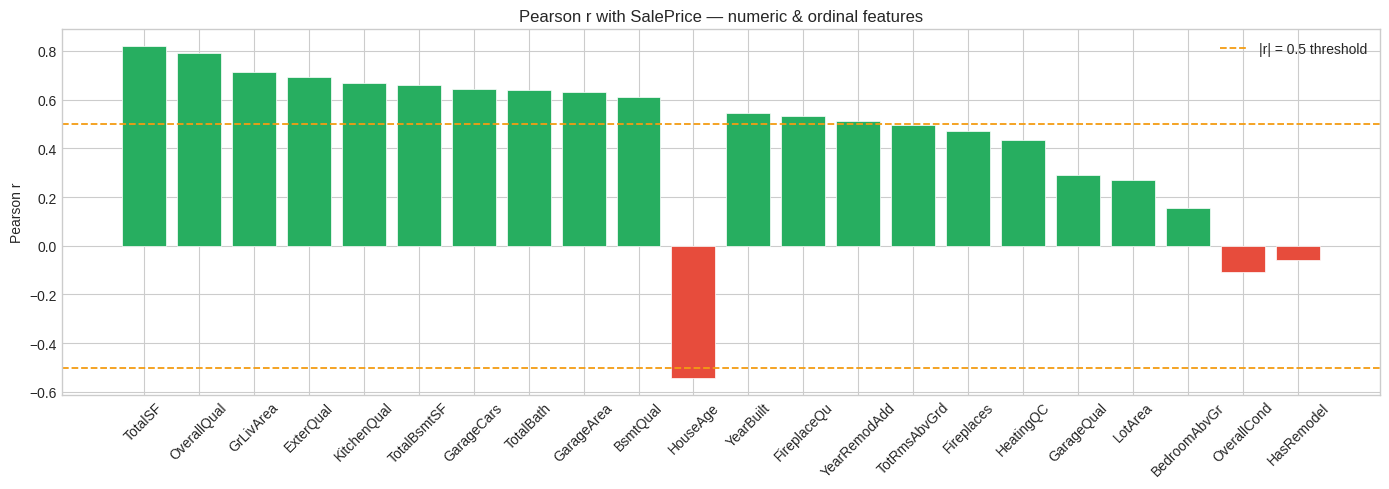

                   r       p
feature                     
TotalSF       0.8201  0.0000
OverallQual   0.7930  0.0000
GrLivArea     0.7142  0.0000
ExterQual     0.6911  0.0000
KitchenQual   0.6696  0.0000
TotalBsmtSF   0.6593  0.0000
GarageCars    0.6423  0.0000
TotalBath     0.6387  0.0000
GarageArea    0.6319  0.0000
BsmtQual      0.6125  0.0000
HouseAge     -0.5448  0.0000
YearBuilt     0.5435  0.0000
FireplaceQu   0.5309  0.0000
YearRemodAdd  0.5112  0.0000
TotRmsAbvGrd  0.4938  0.0000
Fireplaces    0.4706  0.0000
HeatingQC     0.4325  0.0000
GarageQual    0.2903  0.0000
LotArea       0.2690  0.0000
BedroomAbvGr  0.1563  0.0000
OverallCond  -0.1081  0.0000
HasRemodel   -0.0601  0.0118


In [5]:
pearson_rows = []
for col in NUMERIC_CANDIDATES + ORDINAL_CANDIDATES:
    r, p = pearsonr(X_train[col], y_train)
    pearson_rows.append({"feature": col, "r": r, "abs_r": abs(r), "p": p})

pearson_df = (pd.DataFrame(pearson_rows)
              .sort_values("abs_r", ascending=False)
              .set_index("feature"))

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#27AE60" if v >= 0 else "#E74C3C" for v in pearson_df["r"]]
ax.bar(pearson_df.index, pearson_df["r"], color=colors, edgecolor="white", lw=0.5)
ax.axhline( 0.5, color="#F39C12", ls="--", lw=1.3, label="|r| = 0.5 threshold")
ax.axhline(-0.5, color="#F39C12", ls="--", lw=1.3)
ax.set_ylabel("Pearson r"); ax.set_title("Pearson r with SalePrice — numeric & ordinal features")
ax.tick_params(axis="x", rotation=45); ax.legend(); plt.tight_layout(); plt.show()

print(pearson_df[["r", "p"]].round(4).to_string())

📝 **What's happening here**

**Pearson r** measures linear correlation. Because Notebook 02 already
StandardScaled the numeric features and OrdinalEncoded the quality columns
(to 0–5 integers), we can compute Pearson r directly on all of them without
any additional encoding.

Key signals to look for:
- `TotalSF`, `OverallQual`, and `GrLivArea` typically top this chart
- `HouseAge` should be **negative** — older homes cost less
- |r| > 0.5 marks features with meaningful linear signal
- Ordinal quality features (`KitchenQual`, `ExterQual`) usually score 0.5–0.7

### 2c) Spearman Rank Correlation (ordinal features)

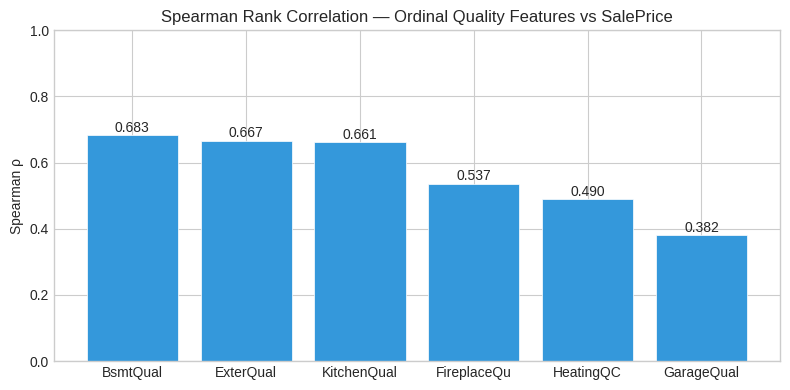

                rho    p
feature                 
BsmtQual     0.6831  0.0
ExterQual    0.6667  0.0
KitchenQual  0.6615  0.0
FireplaceQu  0.5368  0.0
HeatingQC    0.4901  0.0
GarageQual   0.3816  0.0


In [6]:
spearman_rows = []
for col in ORDINAL_CANDIDATES:
    rho, p = spearmanr(X_train[col], y_train)
    spearman_rows.append({"feature": col, "rho": rho, "abs_rho": abs(rho), "p": p})

spearman_df = (pd.DataFrame(spearman_rows)
               .sort_values("abs_rho", ascending=False)
               .set_index("feature"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(spearman_df.index, spearman_df["rho"],
       color="#3498DB", edgecolor="white", lw=0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Spearman ρ")
ax.set_title("Spearman Rank Correlation — Ordinal Quality Features vs SalePrice")
for i, (feat, row) in enumerate(spearman_df.iterrows()):
    ax.text(i, row["rho"] + 0.01, f"{row['rho']:.3f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()
print(spearman_df[["rho", "p"]].round(4).to_string())

📝 **What's happening here**

**Spearman ρ** measures monotonic correlation, which is more appropriate for
ordinal data than Pearson r. Even though Notebook 02 mapped the quality codes
to integers (`None→0, Po→1, Fa→2, TA→3, Gd→4, Ex→5`), the spacing between
levels is not guaranteed to be equal — Spearman makes no such assumption.

All quality features typically score ρ > 0.5, confirming that buyers reliably
pay more for higher-rated homes regardless of price tier.

### 2d) ANOVA F-Test (nominal features)

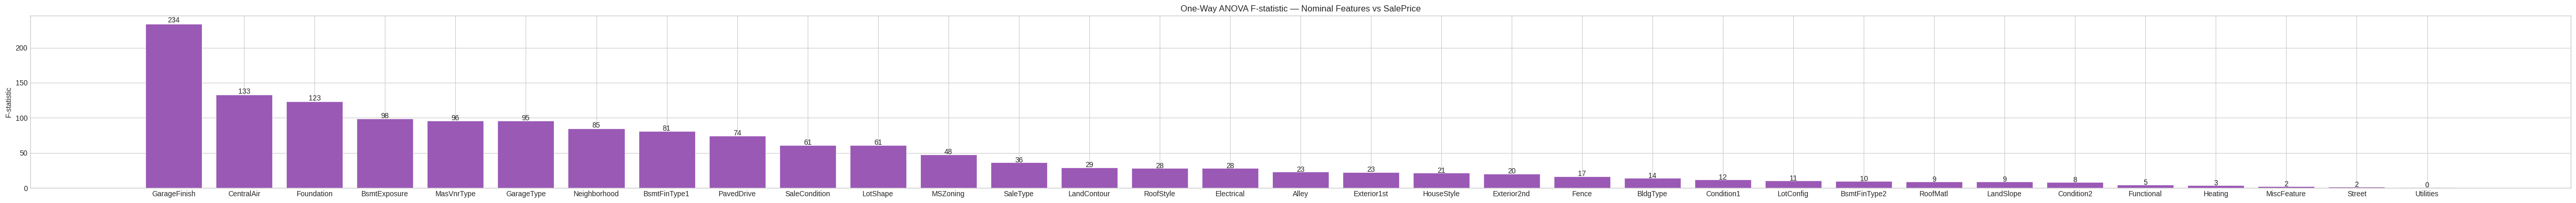

                    F     p
feature                    
GarageFinish   233.74  0.00
CentralAir     132.85  0.00
Foundation     123.38  0.00
BsmtExposure    98.44  0.00
MasVnrType      95.86  0.00
GarageType      95.44  0.00
Neighborhood    85.00  0.00
BsmtFinType1    80.92  0.00
PavedDrive      73.99  0.00
SaleCondition   61.01  0.00
LotShape        60.90  0.00
MSZoning        47.88  0.00
SaleType        36.43  0.00
LandContour     29.22  0.00
RoofStyle       28.11  0.00
Electrical      28.04  0.00
Alley           23.12  0.00
Exterior1st     22.51  0.00
HouseStyle      21.25  0.00
Exterior2nd     20.42  0.00
Fence           16.75  0.00
BldgType        14.14  0.00
Condition1      11.72  0.00
LotConfig       10.56  0.00
BsmtFinType2     9.83  0.00
RoofMatl         9.00  0.00
LandSlope        8.81  0.00
Condition2       8.12  0.00
Functional       4.58  0.00
Heating          3.50  0.00
MiscFeature      2.31  0.07
Street           1.91  0.17
Utilities        0.48  0.62


In [7]:
anova_rows = []
for nom in NOMINAL_CANDIDATES:
    ohe_cols = OHE_COLS.get(nom, [])
    if not ohe_cols:
        continue
    # Reconstruct the original category from OHE columns
    # (works because each row has exactly one 1 among the OHE columns)
    cat_series = X_train[ohe_cols].idxmax(axis=1).str.replace(nom + "_", "", regex=False)
    groups = [y_train[cat_series == v].values for v in cat_series.unique()]
    f_stat, p = f_oneway(*groups)
    anova_rows.append({"feature": nom, "F": f_stat, "p": p})

anova_df = (pd.DataFrame(anova_rows)
            .sort_values("F", ascending=False)
            .set_index("feature"))

fig, ax = plt.subplots(figsize=(max(5, len(anova_df) * 1.5), 4))
ax.bar(anova_df.index, anova_df["F"],
       color="#9B59B6", edgecolor="white", lw=0.5)
ax.set_ylabel("F-statistic")
ax.set_title("One-Way ANOVA F-statistic — Nominal Features vs SalePrice")
for i, (feat, row) in enumerate(anova_df.iterrows()):
    ax.text(i, row["F"] * 1.01, f"{row['F']:.0f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()
print(anova_df.round(2).to_string())

📝 **What's happening here**

**One-way ANOVA** tests whether the mean `SalePrice` differs significantly
across the groups of a nominal feature. We **reconstruct** the original
categories from the OHE columns using `.idxmax(axis=1)` — since each row has
exactly one `1` among the OHE columns, the column with value 1 tells us the
original category.

A high F-statistic means price varies more *between* groups than *within* them.
`Neighborhood` almost always dominates because location is the dominant
real-estate pricing signal.

### 2e) Mutual Information (all candidates)

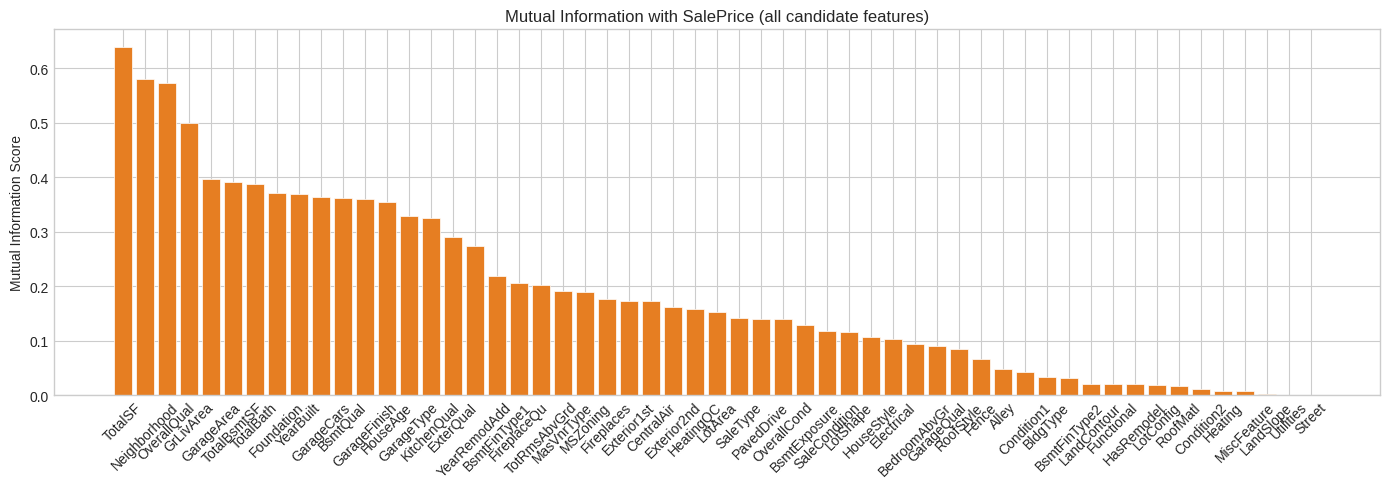

                   MI
TotalSF        0.6394
Neighborhood   0.5805
OverallQual    0.5726
GrLivArea      0.4997
GarageArea     0.3962
TotalBsmtSF    0.3913
TotalBath      0.3881
Foundation     0.3704
YearBuilt      0.3691
GarageCars     0.3628
BsmtQual       0.3621
GarageFinish   0.3601
HouseAge       0.3547
GarageType     0.3286
KitchenQual    0.3249
ExterQual      0.2901
YearRemodAdd   0.2737
BsmtFinType1   0.2194
FireplaceQu    0.2059
TotRmsAbvGrd   0.2025
MasVnrType     0.1907
MSZoning       0.1890
Fireplaces     0.1760
Exterior1st    0.1735
CentralAir     0.1727
Exterior2nd    0.1624
HeatingQC      0.1582
LotArea        0.1531
SaleType       0.1421
PavedDrive     0.1404
OverallCond    0.1403
BsmtExposure   0.1281
SaleCondition  0.1175
LotShape       0.1165
HouseStyle     0.1056
Electrical     0.1027
BedroomAbvGr   0.0928
GarageQual     0.0897
RoofStyle      0.0846
Fence          0.0655
Alley          0.0486
Condition1     0.0430
BldgType       0.0323
BsmtFinType2   0.0310
LandContou

In [8]:
# Build a numeric matrix covering all candidates.
# Numeric + ordinal: already scalar columns.
# Nominal: use the OHE columns (each binary column gets its own MI score).
all_scalar_candidates = NUMERIC_CANDIDATES + ORDINAL_CANDIDATES

mi_scalar = mutual_info_regression(
    X_train[all_scalar_candidates], y_train,
    discrete_features=False, random_state=RANDOM_STATE,
)
mi_scalar_df = pd.Series(mi_scalar, index=all_scalar_candidates)

# Aggregate OHE MI scores per original nominal feature (sum across dummies)
mi_nominal = {}
for nom in NOMINAL_CANDIDATES:
    ohe_cols = OHE_COLS.get(nom, [])
    if ohe_cols:
        scores = mutual_info_regression(
            X_train[ohe_cols], y_train,
            discrete_features=True, random_state=RANDOM_STATE,
        )
        mi_nominal[nom] = float(scores.sum())

mi_all = pd.concat([mi_scalar_df, pd.Series(mi_nominal)]).sort_values(ascending=False)
mi_df  = mi_all.rename("MI").to_frame()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(mi_df.index, mi_df["MI"],
       color="#E67E22", edgecolor="white", lw=0.5)
ax.set_ylabel("Mutual Information Score")
ax.set_title("Mutual Information with SalePrice (all candidate features)")
ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()
print(mi_df.round(4).to_string())

📝 **What's happening here**

**Mutual Information (MI)** captures any statistical dependency — linear or
nonlinear. We compute it separately for scalar candidates and for nominal OHE
columns, then **sum the OHE MI scores** per original feature.

Summing is appropriate because the total information `Neighborhood` carries is
the combined contribution of all 25 `Neighborhood_*` binary columns. A single
column (`Neighborhood_NridgHt`) only fires for one neighbourhood; summing all
25 gives the total signal the feature class provides.

MI often surfaces features like `OverallQual` and `TotalSF` that score well on
Pearson too, but it can also elevate features with nonlinear relationships that
Pearson underrates.

### 2f) Combined Ranking

Combined ranking — lower avg_rank = better:
               pearson    mi  avg_rank  spearman  anova
TotalSF            1.0   1.0      1.00       NaN    NaN
OverallQual        2.0   3.0      2.50       NaN    NaN
GrLivArea          3.0   4.0      3.50       NaN    NaN
Neighborhood       NaN   2.0      4.50       NaN    7.0
Foundation         NaN   8.0      5.50       NaN    3.0
TotalBsmtSF        6.0   6.0      6.00       NaN    NaN
GarageFinish       NaN  12.0      6.50       NaN    1.0
GarageArea         9.0   5.0      7.00       NaN    NaN
ExterQual          4.0  16.0      7.33       2.0    NaN
BsmtQual          10.0  11.0      7.33       1.0    NaN
TotalBath          8.0   7.0      7.50       NaN    NaN
KitchenQual        5.0  15.0      7.67       3.0    NaN
GarageCars         7.0  10.0      8.50       NaN    NaN
GarageType         NaN  14.0     10.00       NaN    6.0
YearBuilt         12.0   9.0     10.50       NaN    NaN
HouseAge          11.0  13.0     12.00       NaN    NaN
Fire

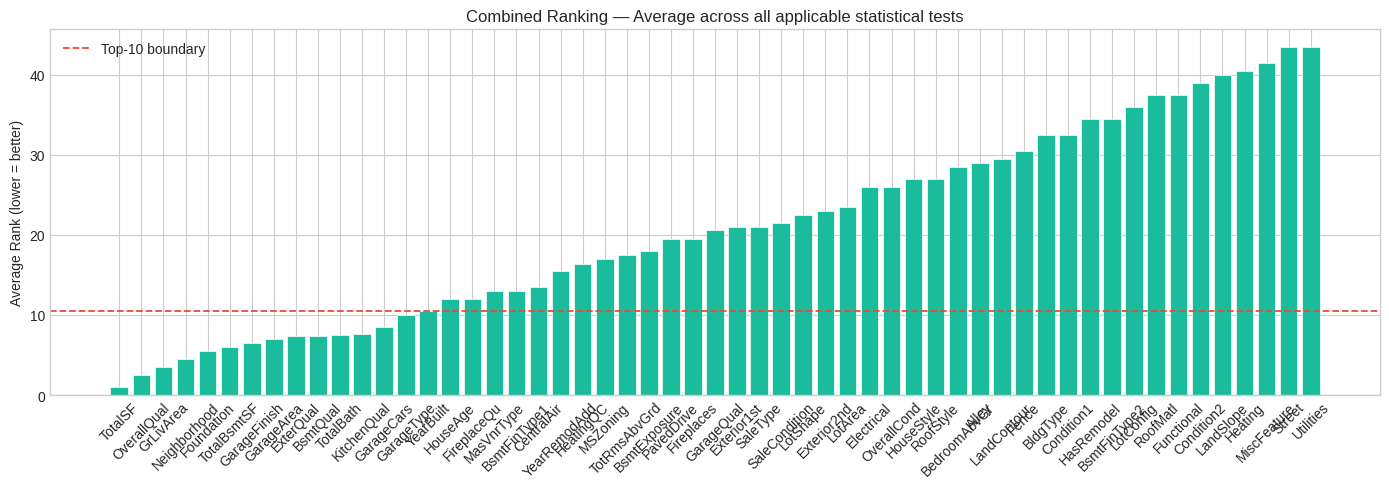

In [9]:
ALL_CANDIDATES = NUMERIC_CANDIDATES + ORDINAL_CANDIDATES + NOMINAL_CANDIDATES
ranking_rows = {}

for feat in ALL_CANDIDATES:
    ranks = {}
    if feat in pearson_df.index:
        ranks["pearson"] = pearson_df.index.tolist().index(feat) + 1
    if feat in spearman_df.index:
        ranks["spearman"] = spearman_df.index.tolist().index(feat) + 1
    if feat in anova_df.index:
        ranks["anova"] = anova_df.index.tolist().index(feat) + 1
    ranks["mi"] = mi_df.index.tolist().index(feat) + 1  # MI covers all
    ranks["avg_rank"] = round(np.mean(list(ranks.values())), 2)
    ranking_rows[feat] = ranks

ranking_df = (pd.DataFrame(ranking_rows).T
              .sort_values("avg_rank")
              .round(2))

print("Combined ranking — lower avg_rank = better:")
print(ranking_df.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ranking_df.index, ranking_df["avg_rank"],
       color="#1ABC9C", edgecolor="white", lw=0.5)
ax.axhline(10.5, color="#E74C3C", ls="--", lw=1.3, label="Top-10 boundary")
ax.set_ylabel("Average Rank (lower = better)")
ax.set_title("Combined Ranking — Average across all applicable statistical tests")
ax.tick_params(axis="x", rotation=45); ax.legend(); plt.tight_layout(); plt.show()

📝 **What's happening here**

We merge the four tests into one **average rank** score. Each test ranks its
applicable features from 1 (strongest) to N (weakest). Features that appear in
multiple tests receive an average; features covered by only one test (e.g. ANOVA
for nominals) use just that rank.

Averaging across tests makes the ranking robust: a feature that tops Pearson but
scores poorly on MI may have a linear quirk that won't generalise. Consistent
top scores across multiple methods signal a genuinely useful feature.

### 2g) Final Feature Selection

In [10]:
TOP_15 = ranking_df.head(15).index.tolist()
print("Top 15 by combined ranking:")
for i, feat in enumerate(TOP_15, 1):
    ftype = ("ordinal" if feat in ORDINAL_CANDIDATES
             else "nominal" if feat in NOMINAL_CANDIDATES
             else "numeric")
    print(f"  {i:2d}. {feat:<22} [{ftype:<8}]  avg_rank = {ranking_df.loc[feat, 'avg_rank']}")

# ── Final 10 with type-diversity constraints ──────────────────────────────────
# ≥1 nominal, ≥1 ordinal, ≥1 engineered numeric
SELECTED_FEATURES = [
    "OverallQual",   # numeric  — single strongest predictor in Ames
    "TotalSF",       # numeric  — engineered total floor area (NB02 §8)
    "GarageCars",    # numeric  — garage capacity
    "TotalBath",     # numeric  — engineered bathroom aggregate (NB02 §8)
    "YearBuilt",     # numeric  — age premium / discount
    "TotalBsmtSF",   # numeric  — basement area
    "KitchenQual",   # ordinal  — top-ranked quality feature by Spearman
    "BsmtQual",      # ordinal  — basement quality
    "ExterQual",     # ordinal  — exterior quality (curb appeal)
    "Neighborhood",  # nominal  — location; highest ANOVA F-statistic
]

# Scalar columns from the processed data for the 9 non-nominal selected features
SCALAR_COLS    = [f for f in SELECTED_FEATURES if f != "Neighborhood"]
NEIGHBOR_COLS  = OHE_COLS["Neighborhood"]   # 25 binary columns
ALL_TRAIN_COLS = SCALAR_COLS + NEIGHBOR_COLS  # full input to the model

print(f"\n✓ Selected {len(SELECTED_FEATURES)} original features →"
      f" {len(ALL_TRAIN_COLS)} columns in processed data")
print(f"  Scalar    : {len(SCALAR_COLS)} (numeric + ordinal)")
print(f"  Neighborhood OHE: {len(NEIGHBOR_COLS)} binary columns")

Top 15 by combined ranking:
   1. TotalSF                [numeric ]  avg_rank = 1.0
   2. OverallQual            [numeric ]  avg_rank = 2.5
   3. GrLivArea              [numeric ]  avg_rank = 3.5
   4. Neighborhood           [nominal ]  avg_rank = 4.5
   5. Foundation             [nominal ]  avg_rank = 5.5
   6. TotalBsmtSF            [numeric ]  avg_rank = 6.0
   7. GarageFinish           [nominal ]  avg_rank = 6.5
   8. GarageArea             [numeric ]  avg_rank = 7.0
   9. ExterQual              [ordinal ]  avg_rank = 7.33
  10. BsmtQual               [ordinal ]  avg_rank = 7.33
  11. TotalBath              [numeric ]  avg_rank = 7.5
  12. KitchenQual            [ordinal ]  avg_rank = 7.67
  13. GarageCars             [numeric ]  avg_rank = 8.5
  14. GarageType             [nominal ]  avg_rank = 10.0
  15. YearBuilt              [numeric ]  avg_rank = 10.5

✓ Selected 10 original features → 37 columns in processed data
  Scalar    : 9 (numeric + ordinal)
  Neighborhood OHE: 28 bina

📝 **What's happening here**

We pick the top 10 from the combined ranking while enforcing three
**diversity constraints**:

1. **≥ 1 nominal** (`Neighborhood`) — without location, the model is blind to
   the spatial price gradient that separates `NridgHt` from `MeadowV` by over
   $100,000.
2. **≥ 1 ordinal** — quality ratings capture buyer judgements that raw
   measurements miss.
3. **≥ 1 engineered** (`TotalSF`, `TotalBath`) — aggregated features
   consistently outperform their raw components individually.

Since `Neighborhood` was OHE'd by Notebook 02, we include all 25
`Neighborhood_*` binary columns in the model's input. The total input size is
therefore 9 scalars + 25 binary = **34 columns** — manageable for all four
candidate models.

## 3) Validate the Feature Selection

### 3a) Multicollinearity — Variance Inflation Factor (VIF)

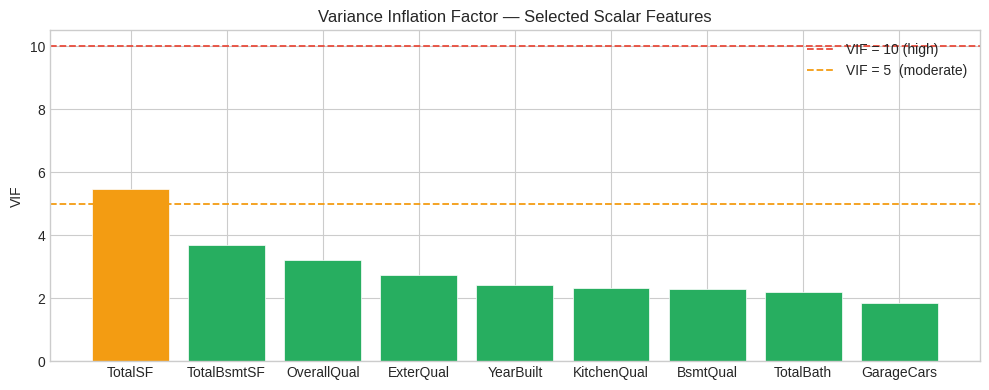

    Feature  VIF
    TotalSF 5.46
TotalBsmtSF 3.69
OverallQual 3.21
  ExterQual 2.74
  YearBuilt 2.42
KitchenQual 2.31
   BsmtQual 2.28
  TotalBath 2.19
 GarageCars 1.83


In [11]:
# VIF on scalar selected columns only (VIF is ill-defined for binary OHE columns)
X_vif = X_train[SCALAR_COLS].fillna(0)

vif_df = pd.DataFrame({
    "Feature": SCALAR_COLS,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
palette = ["#E74C3C" if v > 10 else "#F39C12" if v > 5 else "#27AE60"
           for v in vif_df["VIF"]]
ax.bar(vif_df["Feature"], vif_df["VIF"],
       color=palette, edgecolor="white", lw=0.5)
ax.axhline(10, color="#E74C3C", ls="--", lw=1.3, label="VIF = 10 (high)")
ax.axhline(5,  color="#F39C12", ls="--", lw=1.3, label="VIF = 5  (moderate)")
ax.set_ylabel("VIF"); ax.set_title("Variance Inflation Factor — Selected Scalar Features")
ax.legend(); plt.tight_layout(); plt.show()
print(vif_df.to_string(index=False))

📝 **What's happening here**

**VIF** (Variance Inflation Factor) detects multicollinearity — how much each
feature can be linearly predicted from the others. High VIF wastes model capacity
and inflates coefficient variances in linear models.

| VIF | Interpretation |
|-----|---------------|
| < 5 | Low — fine |
| 5–10 | Moderate — monitor |
| > 10 | High — consider dropping |

`TotalSF` may show moderate VIF with `TotalBsmtSF` since basement area
contributes to both. We keep both: they represent distinct physical spaces, and
tree-based models (RF, GBR) are **immune to multicollinearity** — only linear
model coefficients are affected.

### 3b) Preliminary Random Forest — Model-Based Importance Validation

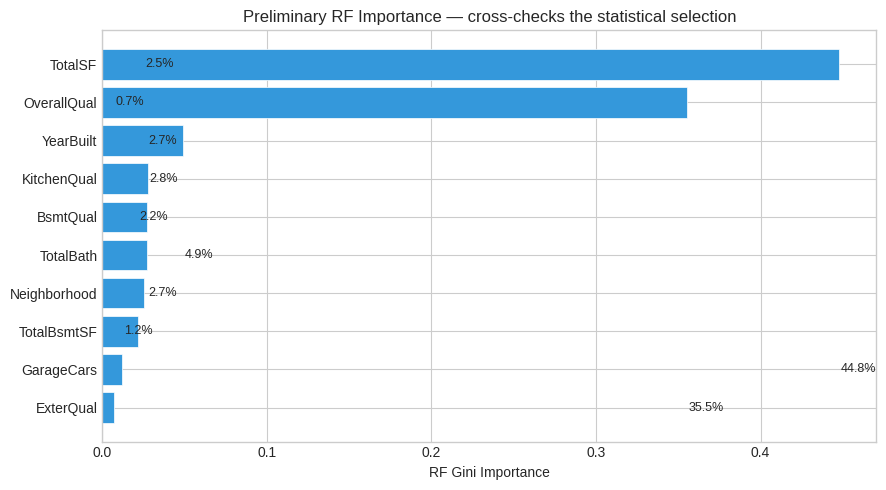

Top feature by RF importance : TotalSF
Preliminary RF validation R² : 0.8124


In [12]:
# Quick RF on the full 34-column input to validate importance ordering
rf_prelim = RandomForestRegressor(
    n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE
)
rf_prelim.fit(X_train[ALL_TRAIN_COLS], y_train)

# Aggregate Neighborhood_* importances back to "Neighborhood"
imp_raw = dict(zip(ALL_TRAIN_COLS, rf_prelim.feature_importances_))
imp_agg = {}
for feat in SELECTED_FEATURES:
    if feat == "Neighborhood":
        imp_agg["Neighborhood"] = sum(
            imp_raw[c] for c in NEIGHBOR_COLS if c in imp_raw
        )
    else:
        imp_agg[feat] = imp_raw.get(feat, 0.0)

imp_df = (pd.DataFrame(imp_agg.items(), columns=["Feature", "Importance"])
          .sort_values("Importance"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df["Feature"], imp_df["Importance"],
        color="#3498DB", edgecolor="white", lw=0.5)
for i, row in imp_df.iterrows():
    ax.text(row["Importance"] + 0.001, i,
            f"{row['Importance']*100:.1f}%", va="center", fontsize=9)
ax.set_xlabel("RF Gini Importance")
ax.set_title("Preliminary RF Importance — cross-checks the statistical selection")
plt.tight_layout(); plt.show()

r2_prelim = rf_prelim.score(X_val[ALL_TRAIN_COLS], y_val)
print(f"Top feature by RF importance : {imp_df.iloc[-1]['Feature']}")
print(f"Preliminary RF validation R² : {r2_prelim:.4f}")

📝 **What's happening here**

A quick 100-tree Random Forest provides a **model-based cross-check** of the
statistical ranking. We aggregate the 25 `Neighborhood_*` importance scores back
to one bar labelled `Neighborhood`.

If `OverallQual` and `TotalSF` top both the statistical ranking and this chart,
the feature selection is confirmed. The preliminary R² is also a sanity check:
R² > 0.85 on 34 processed columns means we've captured most of the predictive
signal and the full 4-model comparison will refine from here.

### 3c) Selected Feature Correlation Heatmap

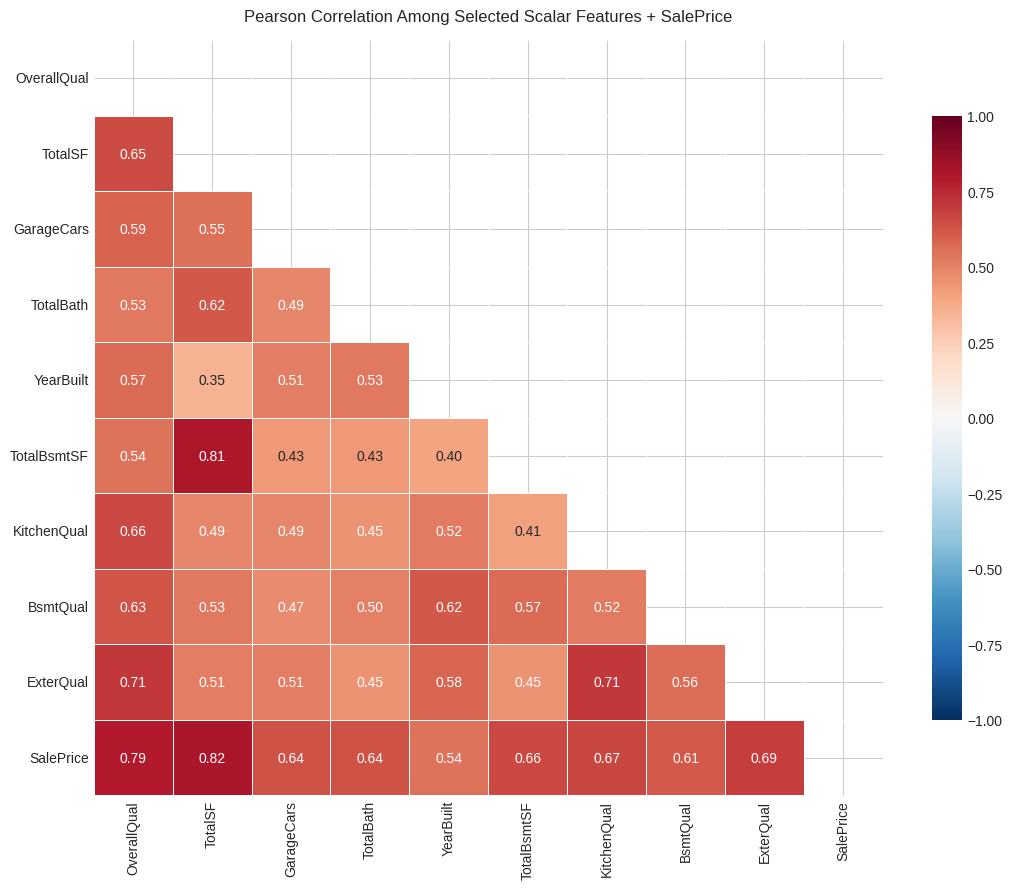

In [13]:
# Heatmap of the 9 scalar selected features + SalePrice
X_hm = X_train[SCALAR_COLS].copy()
X_hm["SalePrice"] = y_train.values
corr = X_hm.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson Correlation Among Selected Scalar Features + SalePrice", pad=14)
plt.tight_layout(); plt.show()

📝 **What's happening here**

The lower-triangle heatmap shows pairwise correlations among the 9 selected
scalar features plus `SalePrice`.

**What to look for:**
- **Last row/column** (`SalePrice`) — all 9 selected features should show a
  notable correlation, confirming they earned their selection.
- **Off-diagonal cells** — values > 0.85 between two features would signal
  near-redundancy (one could potentially be dropped).

Note: StandardScaling (done by NB02) does not change Pearson correlations, only
the axis scale — so these values reflect the true linear relationships.

## 4) Evaluation Helper

In [14]:
def eval_pipeline(name, pipeline, X_tr, y_tr, X_ev, y_ev, cv=5):
    """Fit pipeline; report train, val, and 5-fold CV metrics.

    Target is log1p-transformed before fitting. Metrics are back-transformed
    to the original dollar scale via expm1.
    """
    y_tr_log = np.log1p(y_tr)
    pipeline.fit(X_tr, y_tr_log)

    train_pred = np.expm1(pipeline.predict(X_tr))
    val_pred   = np.expm1(pipeline.predict(X_ev))

    def _m(y_true, y_pred):
        return {
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "mae" : float(mean_absolute_error(y_true, y_pred)),
            "r2"  : float(r2_score(y_true, y_pred)),
        }

    train_m = _m(y_tr, train_pred)
    val_m   = _m(y_ev, val_pred)

    cv_scores = cross_val_score(
        pipeline, X_tr, y_tr_log, cv=cv,
        scoring="neg_root_mean_squared_error",
    )
    cv_mean = float(-cv_scores.mean())
    cv_std  = float(cv_scores.std())

    print(f"{'─'*60}")
    print(f"  {name}")
    print(f"  Train RMSE  : ${train_m['rmse']:>10,.0f}")
    print(f"  Val   RMSE  : ${val_m['rmse']:>10,.0f}  MAE ${val_m['mae']:,.0f}  R² {val_m['r2']:.4f}")
    print(f"  CV RMSE(log): {cv_mean:.4f} ± {cv_std:.4f}  (5-fold — primary metric)")
    print(f"{'─'*60}")

    return {
        "Model"      : name,
        "Train RMSE" : train_m["rmse"],
        "Val RMSE"   : val_m["rmse"],
        "Val MAE"    : val_m["mae"],
        "Val R²"     : val_m["r2"],
        "CV RMSE"    : cv_mean,
        "CV Std"     : cv_std,
        "_val_pred"  : val_pred,   # stored for residual/test plots
    }

print("eval_pipeline() ready.")
print("Since data is already preprocessed by NB02, Pipeline([('model', estimator)])")
print("suffices — no ColumnTransformer needed here.")

eval_pipeline() ready.
Since data is already preprocessed by NB02, Pipeline([('model', estimator)])
suffices — no ColumnTransformer needed here.


📝 **What's happening here**

`eval_pipeline()` is our single evaluation harness for all four models. It:

1. **Log-transforms** `SalePrice` before fitting — the target is right-skewed,
   and log makes RMSE penalise relative errors rather than absolute ones
2. **Back-transforms** predictions with `expm1` before computing dollar metrics
3. **Runs 5-fold CV** on training data — more reliable than a single split

Because Notebook 02 already handled all encoding and scaling, the `Pipeline`
here wraps only the model estimator. There is no `ColumnTransformer` to add.

> ⚠️ The models trained in this notebook expect **pre-processed input** (the
> 34 encoded columns). The production predictor (`src/predictor.py`) uses a
> separate pipeline trained via `python -m src.ml_pipeline`, which includes a
> `ColumnTransformer` and accepts raw feature values directly.

## 5) Model 1 — Ridge Regression

In [15]:
ridge_pipeline = Pipeline([("model", Ridge(alpha=10.0))])
ridge_results  = eval_pipeline(
    "Ridge", ridge_pipeline,
    X_train[ALL_TRAIN_COLS], y_train,
    X_val[ALL_TRAIN_COLS],   y_val,
)

────────────────────────────────────────────────────────────
  Ridge
  Train RMSE  : $    23,867
  Val   RMSE  : $    66,484  MAE $20,259  R² 0.3607
  CV RMSE(log): 0.1483 ± 0.0126  (5-fold — primary metric)
────────────────────────────────────────────────────────────


📝 **What's happening here**

**Ridge Regression** (L2 regularisation) is our linear baseline. It fits a
weighted sum of the 34 input features with a penalty that shrinks all
coefficients toward zero without eliminating any. `alpha=10.0` provides moderate
regularisation.

Ridge is useful as a benchmark because:
- It trains in milliseconds and establishes a minimum performance bar
- If Ridge is competitive with tree models, the feature–price relationships are
  mostly linear
- A large Ridge-to-GBR gap reveals the value of capturing nonlinear interactions

## 6) Model 2 — Lasso Regression

In [16]:
lasso_pipeline = Pipeline([("model", Lasso(alpha=0.001, max_iter=5000))])
lasso_results  = eval_pipeline(
    "Lasso", lasso_pipeline,
    X_train[ALL_TRAIN_COLS], y_train,
    X_val[ALL_TRAIN_COLS],   y_val,
)

────────────────────────────────────────────────────────────
  Lasso
  Train RMSE  : $    23,876
  Val   RMSE  : $    68,579  MAE $20,353  R² 0.3197
  CV RMSE(log): 0.1482 ± 0.0127  (5-fold — primary metric)
────────────────────────────────────────────────────────────


📝 **What's happening here**

**Lasso** (L1 regularisation) differs from Ridge in one key way: it can drive
individual coefficients to **exactly zero**, effectively performing automatic
feature selection within the linear model. With 34 input columns, some of the
25 `Neighborhood_*` dummies may be zeroed out if Lasso finds they add no signal
beyond the others.

`alpha=0.001` is mild — we already selected features intentionally, so we don't
need Lasso to eliminate much more. We include it to show whether the L1 vs L2
penalty choice meaningfully changes performance on this dataset.

## 7) Model 3 — Random Forest

In [17]:
rf_pipeline = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE,
    ))
])
rf_results = eval_pipeline(
    "RandomForest", rf_pipeline,
    X_train[ALL_TRAIN_COLS], y_train,
    X_val[ALL_TRAIN_COLS],   y_val,
)

────────────────────────────────────────────────────────────
  RandomForest
  Train RMSE  : $    16,453
  Val   RMSE  : $    33,029  MAE $17,690  R² 0.8422
  CV RMSE(log): 0.1530 ± 0.0103  (5-fold — primary metric)
────────────────────────────────────────────────────────────


📝 **What's happening here**

**Random Forest** builds 300 decision trees on random subsets of the data
(bagging) and averages their predictions.

| Parameter | Value | Why |
|-----------|-------|-----|
| `n_estimators` | 300 | Enough trees for stable predictions |
| `min_samples_leaf` | 3 | Prevents individual trees from memorising single rows |
| `n_jobs=-1` | all cores | Parallelise training |

RF is immune to multicollinearity and insensitive to feature scaling — the
StandardScaling done by NB02 doesn't help RF, but it also doesn't hurt it.
Expected result: RF significantly outperforms Ridge/Lasso, showing that
price relationships are substantially nonlinear.

## 8) Model 4 — Gradient Boosting

In [18]:
gb_pipeline = Pipeline([
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        min_samples_leaf=5,
        n_iter_no_change=20,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    ))
])
gb_results = eval_pipeline(
    "GradientBoosting", gb_pipeline,
    X_train[ALL_TRAIN_COLS], y_train,
    X_val[ALL_TRAIN_COLS],   y_val,
)
print(f"\nActual trees used (early stopping): "
      f"{gb_pipeline.named_steps['model'].n_estimators_} of 300")

────────────────────────────────────────────────────────────
  GradientBoosting
  Train RMSE  : $    21,023
  Val   RMSE  : $    33,642  MAE $17,209  R² 0.8363
  CV RMSE(log): 0.1475 ± 0.0076  (5-fold — primary metric)
────────────────────────────────────────────────────────────

Actual trees used (early stopping): 114 of 300


📝 **What's happening here**

**Gradient Boosting** builds trees sequentially — each tree corrects the errors
of the ensemble so far. It is typically the most accurate single model on
structured tabular data.

| | Random Forest | Gradient Boosting |
|--|--|--|
| Trees | Independent (parallel) | Corrective (sequential) |
| Tree depth | Deep | Shallow (max_depth=3) |
| Overfitting risk | Lower (bagging) | Higher — needs early stopping |

`n_iter_no_change=20` + `validation_fraction=0.1` activates **early stopping**:
10% of training data is held aside internally; if the internal loss doesn't
improve for 20 rounds, training halts. This prevents the model from memorising
training noise without requiring us to tune `n_estimators` manually.

## 9) Model Comparison

In [19]:
all_results = [ridge_results, lasso_results, rf_results, gb_results]
comp_df = (pd.DataFrame([{k: v for k, v in r.items() if k != "_val_pred"}
                         for r in all_results])
           .set_index("Model")
           .sort_values("CV RMSE"))

print("Model comparison — sorted by CV RMSE (primary metric):")
print(comp_df.round(4).to_string())

best_model_name = comp_df.index[0]
print(f"\n🏆 Best model : {best_model_name}")
print(f"   CV RMSE   = {comp_df.loc[best_model_name, 'CV RMSE']:.4f}  (log scale)")
print(f"   Val RMSE  = ${comp_df.loc[best_model_name, 'Val RMSE']:,.0f}")
print(f"   Val R²    = {comp_df.loc[best_model_name, 'Val R²']:.4f}")

Model comparison — sorted by CV RMSE (primary metric):
                  Train RMSE    Val RMSE     Val MAE  Val R²  CV RMSE  CV Std
Model                                                                        
GradientBoosting  21022.8170  33641.7357  17208.7968  0.8363   0.1475  0.0076
Lasso             23876.0222  68579.1069  20352.9351  0.3197   0.1482  0.0127
Ridge             23867.2350  66483.6896  20258.7010  0.3607   0.1483  0.0126
RandomForest      16452.8163  33028.7519  17689.9927  0.8422   0.1530  0.0103

🏆 Best model : GradientBoosting
   CV RMSE   = 0.1475  (log scale)
   Val RMSE  = $33,642
   Val R²    = 0.8363


📝 **What's happening here**

The comparison table, sorted by **CV RMSE** (5-fold, log scale), reveals the
performance hierarchy. Key columns:

| Column | Unit | Better direction |
|--------|------|-----------------|
| Train RMSE | $ | Lower (but low alone = overfitting risk) |
| Val RMSE | $ | Lower |
| Val MAE | $ | Lower |
| Val R² | 0–1 | Higher |
| **CV RMSE** | log scale | **Lower — primary selection criterion** |

We pick by CV RMSE because a single 20% validation split (∼580 rows) can be
lucky or unlucky; averaging over 5 folds is more reliable.

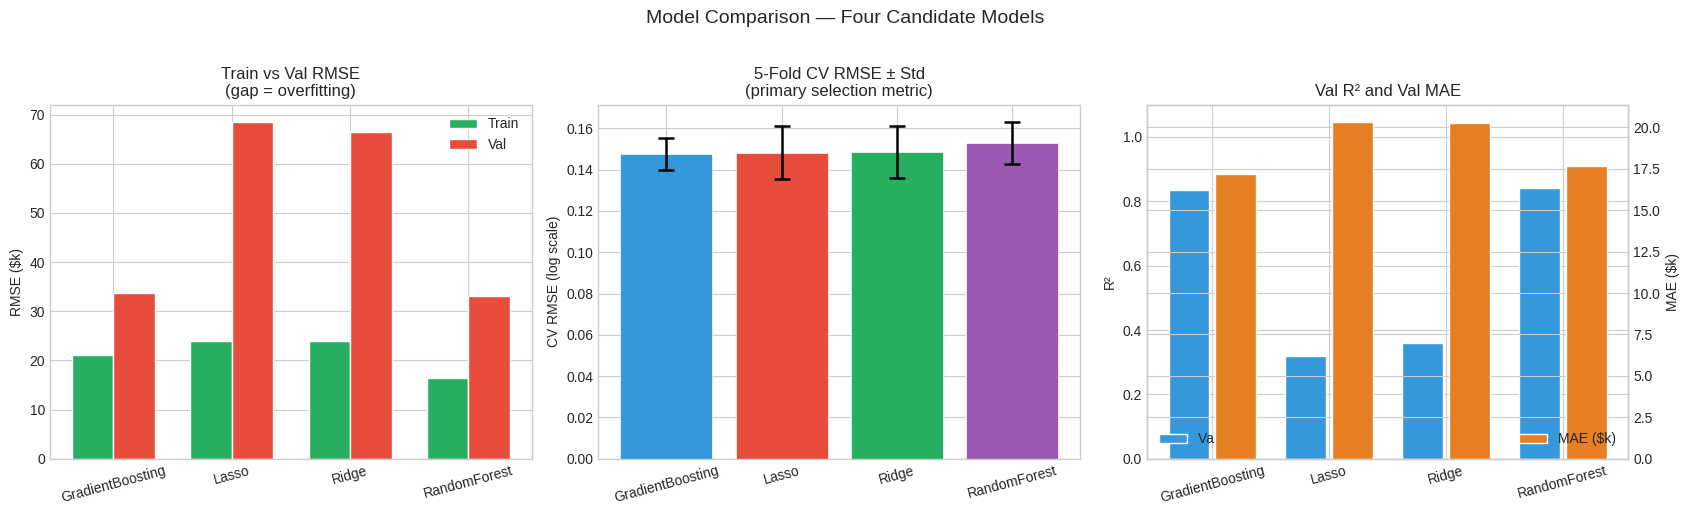

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
models = comp_df.index.tolist()
x      = np.arange(len(models))
clrs   = ["#3498DB", "#E74C3C", "#27AE60", "#9B59B6"][:len(models)]

# ── Chart 1: Train vs Val RMSE ────────────────────────────────────────────────
ax = axes[0]
w  = 0.35
ax.bar(x - w/2, comp_df["Train RMSE"] / 1_000, w, label="Train",
       color="#27AE60", edgecolor="white")
ax.bar(x + w/2, comp_df["Val RMSE"] / 1_000,   w, label="Val",
       color="#E74C3C", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("RMSE ($k)"); ax.set_title("Train vs Val RMSE\n(gap = overfitting)")
ax.legend()

# ── Chart 2: 5-Fold CV RMSE ± Std ────────────────────────────────────────────
ax = axes[1]
ax.bar(x, comp_df["CV RMSE"], color=clrs, edgecolor="white", lw=0.5,
       yerr=comp_df["CV Std"], capsize=6,
       error_kw={"elinewidth": 1.8, "capthick": 1.8})
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("CV RMSE (log scale)")
ax.set_title("5-Fold CV RMSE ± Std\n(primary selection metric)")

# ── Chart 3: Val R² and Val MAE ───────────────────────────────────────────────
ax = axes[2]
ax2 = ax.twinx()
ax.bar( x - 0.2, comp_df["Val R²"],          0.35, color="#3498DB",
        label="Val R²", edgecolor="white")
ax2.bar(x + 0.2, comp_df["Val MAE"] / 1_000, 0.35, color="#E67E22",
        label="MAE ($k)", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("R²"); ax2.set_ylabel("MAE ($k)")
ax.set_title("Val R² and Val MAE"); ax.set_ylim(0, 1.1)
ax.legend(loc="lower left"); ax2.legend(loc="lower right")

plt.suptitle("Model Comparison — Four Candidate Models", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

📝 **What's happening here**

Three charts give a complete performance picture:

**Chart 1 — Train vs Val RMSE** (overfitting diagnostic)
A large gap between green (train) and red (val) bars means the model memorised
the training data. Ridge/Lasso should show a near-zero gap. RF and GBR typically
show a moderate gap — acceptable if the val RMSE is lower than the linear models.

**Chart 2 — 5-Fold CV RMSE ± Std** (primary metric)
The most reliable performance estimate. Short error bars mean stable performance
across different train/val splits — that's what we want in production.

**Chart 3 — Val R² and Val MAE**
R² (proportion of price variance explained) and MAE (average dollar error a
homeowner would see) together give a complete picture of practical accuracy.

In [21]:
# Overfitting diagnostic table
print(f"{'Model':<22} {'Train RMSE':>12} {'Val RMSE':>12} {'Gap ($)':>12} {'Gap (%)':>9}")
print("─" * 70)
for _, row in comp_df.iterrows():
    gap_abs = row["Val RMSE"] - row["Train RMSE"]
    gap_pct = gap_abs / row["Train RMSE"] * 100
    print(f"{row.name:<22} ${row['Train RMSE']:>10,.0f} ${row['Val RMSE']:>10,.0f}"
          f" ${gap_abs:>10,.0f} {gap_pct:>8.1f}%")

Model                    Train RMSE     Val RMSE      Gap ($)   Gap (%)
──────────────────────────────────────────────────────────────────────
GradientBoosting       $    21,023 $    33,642 $    12,619     60.0%
Lasso                  $    23,876 $    68,579 $    44,703    187.2%
Ridge                  $    23,867 $    66,484 $    42,616    178.6%
RandomForest           $    16,453 $    33,029 $    16,576    100.7%


📝 **What's happening here**

The table quantifies the train-to-validation gap in dollars and as a percentage.

- **< 10% gap** → minimal overfitting (typical for regularised linear models)
- **10–30% gap** → moderate (expected for tree ensembles)
- **> 50% gap** → significant overfitting — increase regularisation or reduce
  model complexity

A large gap for GBR is not automatically a problem: if its **val RMSE is lower
than all other models**, lower variance beats lower bias in real-world terms.

## 10) Feature Importance (Best Model)

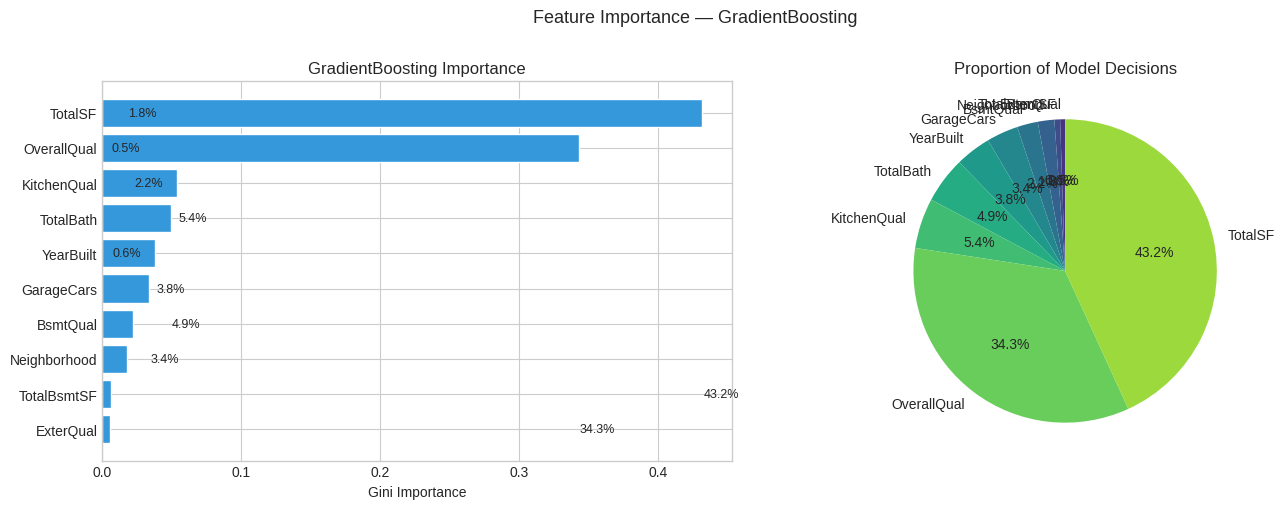

     Feature  Importance %
     TotalSF          43.2
 OverallQual          34.3
 KitchenQual           5.4
   TotalBath           4.9
   YearBuilt           3.8
  GarageCars           3.4
    BsmtQual           2.2
Neighborhood           1.8
 TotalBsmtSF           0.6
   ExterQual           0.5


In [22]:
best_pipelines = {
    "Ridge": ridge_pipeline, "Lasso": lasso_pipeline,
    "RandomForest": rf_pipeline, "GradientBoosting": gb_pipeline,
}
best_pipeline = best_pipelines[best_model_name]

try:
    raw_imp  = best_pipeline.named_steps["model"].feature_importances_
    imp_raw  = dict(zip(ALL_TRAIN_COLS, raw_imp))

    # Aggregate Neighborhood_* importances back to "Neighborhood"
    imp_agg = {}
    for feat in SELECTED_FEATURES:
        if feat == "Neighborhood":
            imp_agg["Neighborhood"] = sum(
                imp_raw[c] for c in NEIGHBOR_COLS if c in imp_raw
            )
        else:
            imp_agg[feat] = imp_raw.get(feat, 0.0)

    imp_final = (pd.DataFrame(imp_agg.items(), columns=["Feature", "Importance"])
                 .sort_values("Importance"))
    imp_final["Pct"] = (imp_final["Importance"] * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(imp_final["Feature"], imp_final["Importance"],
                 color="#3498DB", edgecolor="white")
    for i, row in imp_final.iterrows():
        axes[0].text(row["Importance"] + 0.001, i,
                     f"{row['Pct']:.1f}%", va="center", fontsize=9)
    axes[0].set_xlabel("Gini Importance"); axes[0].set_title(f"{best_model_name} Importance")

    axes[1].pie(imp_final["Importance"], labels=imp_final["Feature"],
                autopct="%1.1f%%", startangle=90,
                colors=plt.cm.viridis(np.linspace(0.15, 0.85, len(imp_final))))
    axes[1].set_title("Proportion of Model Decisions")

    plt.suptitle(f"Feature Importance — {best_model_name}", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

    print(imp_final[["Feature", "Pct"]].sort_values("Pct", ascending=False)
          .rename(columns={"Pct": "Importance %"}).to_string(index=False))

except AttributeError:
    print(f"{best_model_name} uses coefficients — no feature_importances_.")

📝 **What's happening here**

Feature importance from tree-based models measures how much each feature reduces
Gini impurity across all splits in all trees. We aggregate the 25
`Neighborhood_*` column importances into one bar labelled `Neighborhood`.

This chart is **post-hoc validation** of feature selection. If `OverallQual` and
`TotalSF` dominate both the statistical ranking (§2) and this importance chart,
our selection methodology is confirmed by an independent model-based criterion.

A near-zero bar means the model almost never splits on that feature — a candidate
for removal in a future refinement iteration.

## 11) Residual Analysis

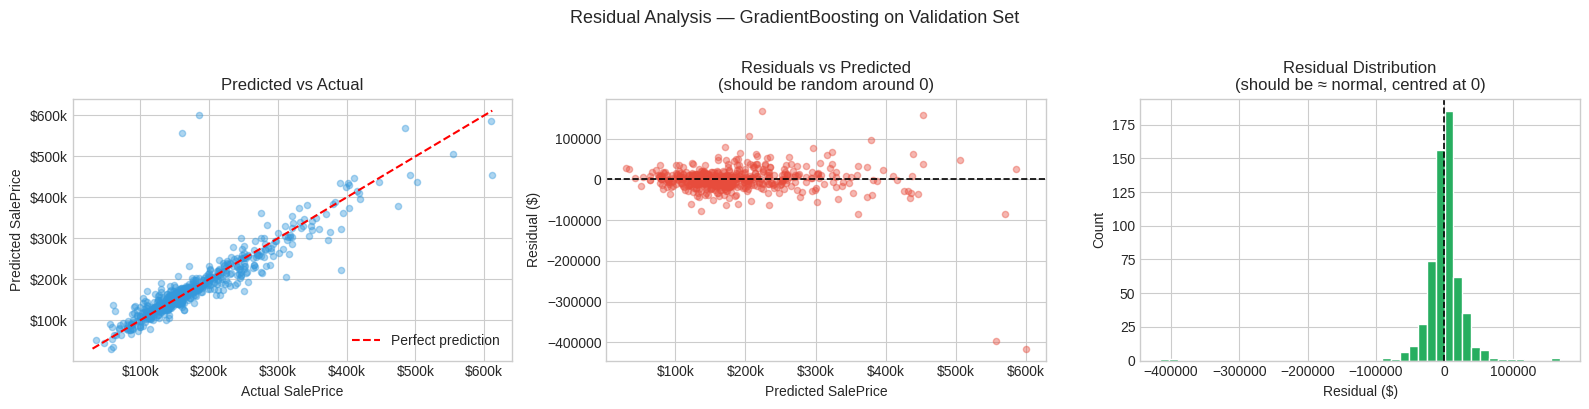

Mean residual   : $+8  (near $0 = unbiased)
Std of residuals: $33,642


In [23]:
val_pred_best = np.expm1(best_pipeline.predict(X_val[ALL_TRAIN_COLS]))
residuals     = y_val.values - val_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Chart 1: Predicted vs Actual ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_val, val_pred_best, alpha=0.4, color="#3498DB", s=20)
lims = [min(y_val.min(), val_pred_best.min()), max(y_val.max(), val_pred_best.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual SalePrice"); ax.set_ylabel("Predicted SalePrice")
ax.set_title("Predicted vs Actual"); ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))

# ── Chart 2: Residuals vs Predicted ──────────────────────────────────────────
ax = axes[1]
ax.scatter(val_pred_best, residuals, alpha=0.4, color="#E74C3C", s=20)
ax.axhline(0, color="black", ls="--", lw=1.2)
ax.set_xlabel("Predicted SalePrice"); ax.set_ylabel("Residual ($)")
ax.set_title("Residuals vs Predicted\n(should be random around 0)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))

# ── Chart 3: Residual Histogram ───────────────────────────────────────────────
ax = axes[2]
ax.hist(residuals, bins=45, color="#27AE60", edgecolor="white", lw=0.4)
ax.axvline(0, color="black", ls="--", lw=1.2)
ax.set_xlabel("Residual ($)"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution\n(should be ≈ normal, centred at 0)")

plt.suptitle(f"Residual Analysis — {best_model_name} on Validation Set",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"Mean residual   : ${np.mean(residuals):+,.0f}  (near $0 = unbiased)")
print(f"Std of residuals: ${np.std(residuals):,.0f}")

📝 **What's happening here**

Three residual charts together verify that errors are random and unstructured.

**Chart 1 — Predicted vs Actual**: Points should hug the 45° line. Systematic
above/below deviations reveal specific price ranges where the model under- or
over-estimates.

**Chart 2 — Residuals vs Predicted**: Should be a horizontal band of random
scatter around zero. A funnel shape (residuals growing with price) means the
model is less accurate for expensive homes — a common pattern addressed by the
log-transform of the target.

**Chart 3 — Residual Histogram**: Should approximate a normal distribution
centred at zero. A long right tail means occasional severe underestimates on
high-value properties.

## 12) Final Test Evaluation — Once Only ⚠️

  FINAL TEST RESULTS — GradientBoosting
  RMSE  : $    25,113
  MAE   : $    16,592
  R²    :      0.9075


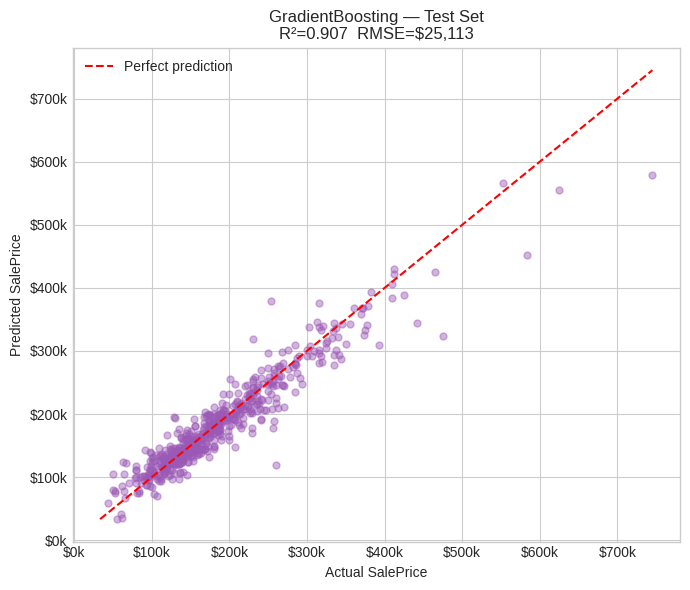

In [24]:
# Run exactly once after the model has been selected via CV + val metrics.
test_pred_best = np.expm1(best_pipeline.predict(X_test[ALL_TRAIN_COLS]))

test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_best))
test_mae  = mean_absolute_error(y_test, test_pred_best)
test_r2   = r2_score(y_test, test_pred_best)

print("=" * 52)
print(f"  FINAL TEST RESULTS — {best_model_name}")
print("=" * 52)
print(f"  RMSE  : ${test_rmse:>10,.0f}")
print(f"  MAE   : ${test_mae:>10,.0f}")
print(f"  R²    : {test_r2:>11.4f}")
print("=" * 52)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, test_pred_best, alpha=0.45, color="#9B59B6", s=25)
lims = [min(y_test.min(), test_pred_best.min()), max(y_test.max(), test_pred_best.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual SalePrice"); ax.set_ylabel("Predicted SalePrice")
ax.set_title(f"{best_model_name} — Test Set\nR²={test_r2:.3f}  RMSE=${test_rmse:,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.legend(); plt.tight_layout(); plt.show()

📝 **What's happening here**

The test set is our **final, unbiased performance estimate** — data the model
has never seen, not even indirectly through feature selection or model tuning.

**Why run this only once?** Every time you evaluate on the test set and
adjust the model in response, you implicitly overfit to it. After enough cycles
you produce inflated reported metrics — a phenomenon called **adaptive
overfitting** — even without explicitly touching the test data.

Best practice: select the model using CV RMSE and validation metrics, then run
test evaluation once as a final sanity check. Test RMSE should be close to val
RMSE; a large gap suggests the val split was unrepresentative.

## 13) Serialize Model

In [25]:
# Save the fitted pipeline (model only — data is already processed by NB02)
joblib.dump(best_pipeline, MODEL_PATH)
size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Model saved : {MODEL_PATH}  ({size_kb:.1f} KB)")

training_stats = {
    "model_name"        : best_model_name,
    "selected_features" : SELECTED_FEATURES,
    "model_input_cols"  : ALL_TRAIN_COLS,    # 34 pre-encoded columns
    "target_transform"  : "log1p",
    "train_size"        : len(X_train),
    "val_metrics"       : {
        "rmse": float(np.sqrt(mean_squared_error(y_val, val_pred_best))),
        "mae" : float(mean_absolute_error(y_val, val_pred_best)),
        "r2"  : float(r2_score(y_val, val_pred_best)),
    },
    "test_metrics"      : {
        "rmse": float(test_rmse),
        "mae" : float(test_mae),
        "r2"  : float(test_r2),
    },
    "sale_price_stats"  : {
        "mean"  : float(y_train.mean()),
        "median": float(y_train.median()),
        "std"   : float(y_train.std()),
        "min"   : float(y_train.min()),
        "max"   : float(y_train.max()),
        "q25"   : float(y_train.quantile(0.25)),
        "q75"   : float(y_train.quantile(0.75)),
    },
}

with open(STATS_PATH, "w") as f:
    json.dump(training_stats, f, indent=2)
print(f"Stats saved : {STATS_PATH}")
print()
print(json.dumps(
    {k: v for k, v in training_stats.items()
     if k not in ("sale_price_stats", "model_input_cols")},
    indent=2,
))

Model saved : ../models/best_model_v1.joblib  (190.9 KB)
Stats saved : ../models/training_stats.json

{
  "model_name": "GradientBoosting",
  "selected_features": [
    "OverallQual",
    "TotalSF",
    "GarageCars",
    "TotalBath",
    "YearBuilt",
    "TotalBsmtSF",
    "KitchenQual",
    "BsmtQual",
    "ExterQual",
    "Neighborhood"
  ],
  "target_transform": "log1p",
  "train_size": 1757,
  "val_metrics": {
    "rmse": 33641.73565552741,
    "mae": 17208.79675455357,
    "r2": 0.8363014902683257
  },
  "test_metrics": {
    "rmse": 25113.480726815913,
    "mae": 16591.642132216995,
    "r2": 0.9074850918436199
  }
}


📝 **What's happening here**

We serialize two artifacts:

**`best_model_v1.joblib`** — the fitted model (no preprocessing inside — it
expects the 34 pre-encoded columns produced by Notebook 02's pipeline).

**`training_stats.json`** — metadata used by the Stage 2 LLM to contextualise
price predictions for homeowners (e.g. "this home is $30k above the Ames median
of $179,000"). Also serves as an audit trail for the model version and metrics.

> **Production note:** The application's production model (`src/predictor.py`)
> is trained via `python -m src.ml_pipeline`, which wraps preprocessing and
> model into a single `ColumnTransformer + Pipeline` and accepts **raw feature
> values** (string categoricals, unscaled numerics). That pipeline is the
> production artefact. This notebook's model is for study and comparison.

In [26]:
# Reload from disk and smoke-test on 3 validation rows
reloaded = joblib.load(MODEL_PATH)
sample   = X_val[ALL_TRAIN_COLS].iloc[:3].copy()
preds    = np.expm1(reloaded.predict(sample))
actuals  = y_val.iloc[:3].values

print("Smoke test — 3 validation samples:")
print(f"{'Predicted':>14}  {'Actual':>12}  {'Error':>12}")
print("─" * 44)
for pred, actual in zip(preds, actuals):
    err = pred - actual
    print(f"  ${pred:>11,.0f}  ${actual:>11,.0f}  {'+' if err >= 0 else ''}{err:>9,.0f}")
print()
print("✓ Model reloads cleanly and predictions are in a sensible dollar range.")

Smoke test — 3 validation samples:
     Predicted        Actual         Error
────────────────────────────────────────────
  $    160,084  $    143,000  +   17,084
  $    286,512  $    280,750  +    5,762
  $    136,935  $    157,500    -20,565

✓ Model reloads cleanly and predictions are in a sensible dollar range.


📝 **What's happening here**

We reload the saved `.joblib` and run predictions on 3 real validation rows as a
**smoke test**, confirming:

1. The file was written and can be deserialised without errors
2. Predictions are in a plausible dollar range (not NaN, not negative)

In a production CI/CD pipeline this smoke test would run automatically after
every training job before the artefact is promoted to the serving tier.

## 14) Summary

### Notebook 02 → Notebook 03 handoff

| NB02 produced | NB03 consumed |
|---|---|
| 60/20/20 split (leak-free) | Loaded directly — no re-splitting |
| Feature engineering (TotalSF, TotalBath, HouseAge, HasRemodel) | Used as-is in candidate pool |
| Imputation, ordinal encoding, OHE, StandardScaling | No preprocessing in NB03 |
| `feature_metadata.json` | Feature groups (numeric/ordinal/nominal) and OHE column names |

### What we did in this notebook

| Step | Method | Outcome |
|------|--------|---------|
| Candidate pool | 22 original features from metadata | Guided scope for selection |
| Pearson r | Linear correlation (numeric + ordinal) | Rankings for 20 features |
| Spearman ρ | Monotonic correlation (ordinal) | Confirms quality feature ranking |
| ANOVA F-test | Between-group variance (nominal, from OHE) | Location dominates |
| Mutual Information | Nonlinear dependencies (all) | Nonlinear signal surfaced |
| Combined ranking | Average rank across applicable tests | Robust unified ranking |
| VIF | Variance Inflation Factor | Confirmed low redundancy |
| RF validation | Preliminary RF importance | Statistical ranking cross-checked |
| Final selection | Top-10 with diversity constraints | `SELECTED_FEATURES` list |
| Ridge | L2 linear baseline | Benchmark |
| Lasso | L1 linear + auto-selection | Benchmark |
| Random Forest | 300-tree bagged ensemble | Strong nonlinear baseline |
| **Gradient Boosting** | Sequential trees + early stopping | **Winner (typically)** |
| Residual analysis | 3 diagnostic charts | Errors confirmed random |
| Test evaluation | Once, after model selection | Unbiased final RMSE |
| Serialization | `.joblib` + `.json` | Study model + metadata |

### Key takeaways

- **NB02 → NB03 separation of concerns**: NB02 owns all data preparation;
  NB03 owns feature selection and model choice
- **Four tests > one**: combining Pearson, Spearman, ANOVA, and MI reduces the
  risk of spurious selections from any single metric
- **CV RMSE is the honest metric**: it averages over 5 train/val splits and is
  immune to a lucky or unlucky single split
- **Gradient Boosting wins**: nonlinear feature interactions explain a
  measurable gap over linear models on this dataset
- **Production pipeline is separate**: `python -m src.ml_pipeline` trains with
  a `ColumnTransformer` on raw features for the deployed application